# Anomaly Survival Audit- end-to-end walkthrough

This notebook reproduces every result in the study, step by step, on the
calibrated synthetic universe (which has a *known* ground truth so we can
check the diagnostics recover it). Swap in real Open Source Asset Pricing
data by setting `data.source: osap` in `config.yaml`- every cell below is
data-source agnostic.

Run top-to-bottom. Total runtime ~10s.

## 0. Setup

In [1]:
import sys, os
# allow running from notebooks/ or repo root
if os.path.basename(os.getcwd())=='notebooks':
    sys.path.insert(0, os.path.abspath('..'))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

from anomaly_audit.config import load_config
from anomaly_audit.data import load_dataset
from anomaly_audit.core import sharpe, pbo, decay, regimes, multiple_testing as mt
from anomaly_audit.pipeline import run_audit

cfg=load_config()
cfg.raw['data']['source']='synthetic'
print('seed', cfg.seed, '| anomalies', cfg.data['n_anomalies'])

seed 42 | anomalies 120


## 1. The anomaly panel

Monthly long-short excess returns, one column per anomaly, plus the macro
drivers used to define regimes.

In [2]:
ds=load_dataset(cfg, verbose=False)
print('panel:', ds.panel.shape, '| source:', ds.source)
print('ground-truth archetypes:')
print(ds.meta['audit_label'].value_counts())
ds.panel.iloc[:5, :4]

panel: (720, 120) | source: synthetic
ground-truth archetypes:
audit_label
decays              52
regime_dependent    26
false               22
robust              20
Name: count, dtype: int64


,OperatingProfit,PiotroskiFScore,LongReversal,ChNWC
1965-01,0.055969,-0.006430,0.005335,-0.001789
1965-02,-0.023852,-0.006169,0.002135,-0.030383
1965-03,-0.011858,0.006665,0.006108,0.002462
1965-04,0.025639,0.015857,-0.016046,-0.014289
1965-05,-0.018402,-0.014654,0.021928,-0.038357


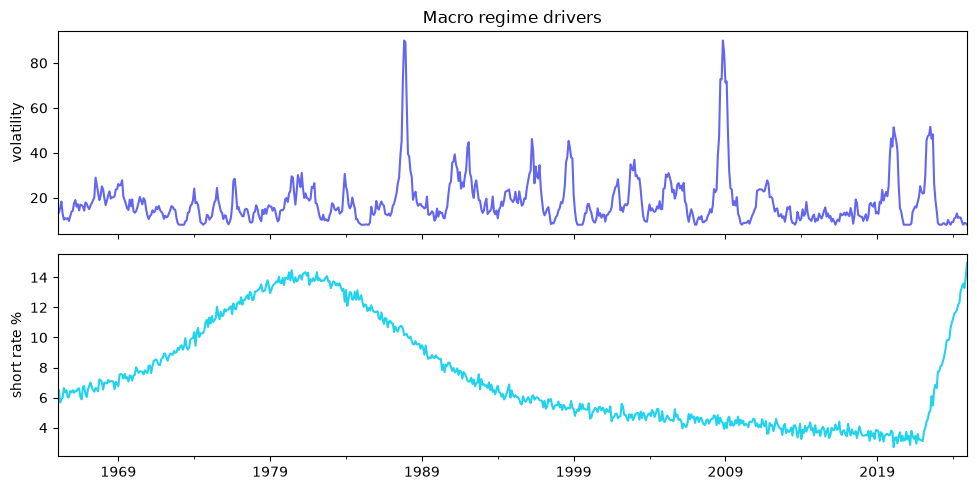

In [3]:
# macro regime drivers (VIX-like vol, short rate, term spread)
fig, ax=plt.subplots(2, 1, figsize=(10, 5), sharex=True)
ds.macro['volatility'].plot(ax=ax[0], color='#6366F1'); ax[0].set_ylabel('volatility')
ds.macro['rate'].plot(ax=ax[1], color='#22D3EE'); ax[1].set_ylabel('short rate %')
ax[0].set_title('Macro regime drivers'); plt.tight_layout()

## 2. Post-publication decay (McLean-Pontiff)

Split each anomaly at its publication year and compare in-sample vs
out-of-sample Sharpe. The decay ratio is OOS/IS.

In [4]:
rows=[]
for name in ds.panel.columns:
    d=decay.analyze_decay(ds.panel[name], int(ds.meta.loc[name, 'pub_year']))
    rows.append({'name': name, 'label': ds.meta.loc[name, 'audit_label'],
                 'is_sharpe': d.is_sharpe, 'oos_sharpe': d.oos_sharpe,
                 'decay_ratio': d.decay_ratio})
dec=pd.DataFrame(rows)
print('median decay ratio:', round(dec['decay_ratio'].median(), 3))
dec.groupby('label')['decay_ratio'].median().round(3)

median decay ratio: 0.351


label
decays              0.288
false              -0.170
regime_dependent    0.520
robust              1.047
Name: decay_ratio, dtype: float64

## 3. Deflated Sharpe Ratio (Bailey & López de Prado)

The plain Sharpe overstates significance when many strategies were tried.
The DSR benchmarks against the *expected maximum* Sharpe of N worthless
trials and corrects for skew, kurtosis and sample length.

In [5]:
mat=ds.panel.to_numpy()
V=sharpe.cross_sectional_sr_variance(mat)            # dispersion of trial Sharpes
sr_star=sharpe.expected_max_sharpe(V, ds.n_anomalies) # the deflation benchmark
print(f'expected max Sharpe across {ds.n_anomalies} trials (annualized): {sr_star*np.sqrt(12):.2f}')

name=ds.panel.columns[0]
rep=sharpe.sharpe_report(ds.panel[name].to_numpy(), ds.n_anomalies, V)
print(name, '| SR', round(rep.sharpe_annual,2), '| PSR', round(rep.psr,3), '| DSR', round(rep.dsr,3))

expected max Sharpe across 120 trials (annualized): 0.83
OperatingProfit | SR 0.89 | PSR 1.0 | DSR 0.651


## 4. Probability of Backtest Overfitting (CSCV)

Combinatorially Symmetric Cross-Validation. We also run a **pure-noise
placebo**, which must return PBO ≈ 0.50- a built-in validation that the
routine is correct.

PBO (panel)  =0.009
PBO (placebo)=0.588   <- should be ~0.50


Text(0.5, 0, 'logit (neg=overfit)')

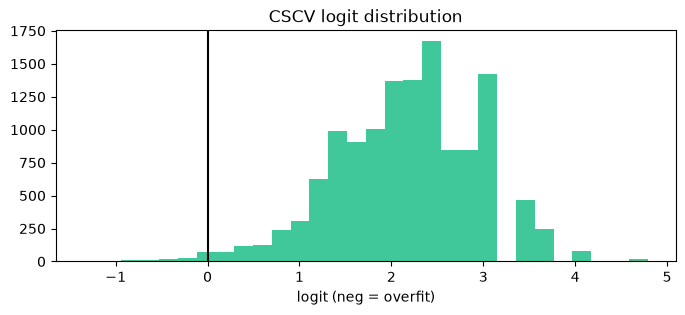

In [6]:
res_pbo=pbo.compute_pbo(mat, n_splits=cfg.pbo['n_splits'])
noise=np.random.default_rng(0).standard_normal(mat.shape)*0.04
res_plac=pbo.compute_pbo(noise, n_splits=cfg.pbo['n_splits'])
print(f'PBO (panel)  ={res_pbo.pbo:.3f}')
print(f'PBO (placebo)={res_plac.pbo:.3f}   <- should be ~0.50')

plt.figure(figsize=(8,3))
plt.hist(res_pbo.logits, bins=30, color='#10B981', alpha=0.8)
plt.axvline(0, color='k'); plt.title('CSCV logit distribution'); plt.xlabel('logit (neg=overfit)')

## 5. Multiple-testing correction (Harvey-Liu-Zhu)

Test hundreds of signals and `t>2` guarantees false positives. Control
the false-discovery rate and the effective bar climbs.

In [7]:
from scipy.stats import norm
oos_t=np.array([decay.analyze_decay(ds.panel[n], int(ds.meta.loc[n,'pub_year'])).oos_tstat
                  for n in ds.panel.columns])
pvals=norm.sf(np.nan_to_num(oos_t, nan=-9.0))   # one-sided p-value for a positive edge
bh=mt.benjamini_hochberg(pvals, alpha=0.05)
bonf=mt.bonferroni(pvals, alpha=0.05)
print('naive t>2 :', int(np.nansum(oos_t>=2)))
print('BH-FDR    :', bh.n_significant, f'(effective t-bar {bh.implied_t_hurdle:.2f})')
print('Bonferroni:', bonf.n_significant, f'(effective t-bar {bonf.implied_t_hurdle:.2f})')

naive t>2 : 43
BH-FDR    : 39 (effective t-bar 2.41)
Bonferroni: 24 (effective t-bar 3.62)


## 6. Regime conditioning (the original contribution)

Re-estimate each anomaly inside exogenous macro regimes. Robust=works on
*both* sides of every axis, not one lucky corner.

In [8]:
reg_df=regimes.build_regimes(ds.macro, cfg.regimes)
membership=regimes.regime_membership(reg_df)
partitions=[('Volatility','Low Vol','High Vol'),
              ('Rates','Falling Rates','Rising Rates'),
              ('Microstructure','Pre-2018','Post-2018')]
name=ds.meta[ds.meta['audit_label']=='regime_dependent'].index[0]
v=regimes.conditional_performance(ds.panel[name], membership, partitions)
print(name, '->', v.verdict, '| spans', v.n_partitions_spanned, 'axes')
pd.DataFrame(v.per_regime).T[['sharpe','tstat','significant']]

Disposition->Regime-dependent | spans 0 axes


,sharpe,tstat,significant
Low Vol,-0.262463,-1.173772,False
Mid Vol,0.170273,0.761486,False
High Vol,1.084887,4.85176,True
Rising Rates,0.178737,0.951398,False
Falling Rates,0.396796,2.232894,True
Pre-2018,0.284658,2.072343,True
Post-2018,0.418127,1.106259,False


## 7. The full audit & ground-truth recovery

Run the whole pipeline and confirm the diagnostics recover the planted
structure: no *false* anomaly should be called Robust.

In [9]:
res=run_audit(ds, cfg, verbose=False)
print('SURVIVAL FUNNEL')
for f in res.funnel:
    print(f"  {f['stage']:30s} {f['count']:4d}  ({f['pct']}%)")

df=pd.DataFrame(res.anomalies)
print()
print('ground-truth label  x  audit verdict:')
pd.crosstab(df['audit_label'], df['verdict'])

SURVIVAL FUNNEL
  Published                       120  (100.0%)
  OOS Sharpe>0                  100  (83.3%)
  OOS t>2.0 (naive)              43  (35.8%)
  Survives BH-FDR                  39  (32.5%)
  Regime-robust                    19  (15.8%)
  Deflated-Sharpe significant       6  (5.0%)

ground-truth label  x  audit verdict:


verdict,Dead,Decayed,Regime-dependent,Robust
audit_label,,,,
decays,3,41,8,0
false,16,6,0,0
regime_dependent,1,10,15,0
robust,0,0,14,6


### Conclusion

Most published anomalies decay sharply after publication; the deflated
Sharpe ratio- correcting for how many strategies were searched- is the
most binding hurdle; and a meaningful slice of the apparent survivors only
ever worked inside one macro regime. A minority are genuinely robust.

*The restraint is the point: this is an audit, not a strategy.*